# 1. First uncomment and  install all the required Packages below.

In [ ]:
# pip install torch torchvision numpy opencv-python
#!pip install --user opencv-python
#!pip install easyocr
#pip install pyspellchecker


# 2. From Installed packages import required libraries

In [1]:
import easyocr
import cv2
from matplotlib import pyplot as plt
import pandas as pd
from spellchecker import SpellChecker

# 3. Provide the path of the image in your local device

In [14]:
image_path= r"C:\Users\ACER\OneDrive\Pictures\Screenshots\Screenshot 2024-04-27 030416.png"

# 4. Read the image using Opencv and matplotlib to visualize it.

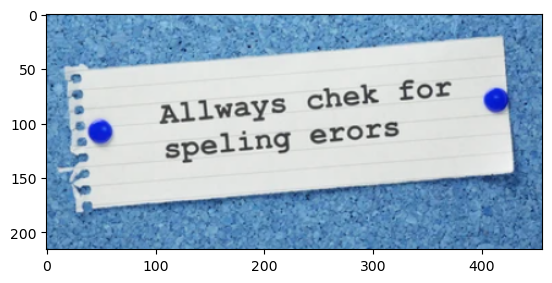

In [15]:
img= cv2.imread(image_path)
plt.imshow(img)
plt.show()

# 5. Reading the text in the image using Easyocr

In [16]:
reader= easyocr.Reader(['en'],gpu=False)
result=reader.readtext(image_path)
result

Using CPU. Note: This module is much faster with a GPU.


[([[320, 56], [376, 56], [376, 82], [320, 82]], 'for', 0.9999684779805031),
 ([[99, 71], [224, 71], [224, 104], [99, 104]], 'Allways', 0.9998959619251854),
 ([[234.3358994113243, 65.50384911698647],
   [307.722687555144, 58.74024904164981],
   [308.6641005886757, 85.49615088301353],
   [235.27731244485605, 92.2597509583502]],
  'chek',
  0.9999643564224243),
 ([[238.07944680100655, 99.69533616120788],
   [327.82135993738194, 91.98023134793424],
   [328.92055319899345, 116.30466383879212],
   [239.17864006261803, 124.01976865206576]],
  'erors',
  0.9999347458423383),
 ([[104.05742827528547, 107.50337089551385],
   [228.77493014408387, 97.67716123156035],
   [229.94257172471453, 132.49662910448615],
   [104.22506985591613, 141.32283876843965]],
  'speling',
  0.9999652609535455)]

# 6. Convert the output into DataFrame using Pandas for better understanding.

In [17]:
df = pd.DataFrame(result, columns= ['Cor','text','confidence'])
df

,Cor,text,confidence
0,"[[320, 56], [376, 56], [376, 82], [320, 82]]",for,0.999968
1,"[[99, 71], [224, 71], [224, 104], [99, 104]]",Allways,0.999896
2,"[[234.3358994113243, 65.50384911698647], [307....",chek,0.999964
3,"[[238.07944680100655, 99.69533616120788], [327...",erors,0.999935
4,"[[104.05742827528547, 107.50337089551385], [22...",speling,0.999965


# 7.  Extract text column from dataframe and store it in s1 as a string.

In [25]:
s = [str(x) for x in df["text"] ] 
s1 = " ".join(s) 
s1

'for Allways chek erors speling'

# 8.  Rectifying the string using Pyspellchecker

In [21]:
spell = SpellChecker()

In [26]:
required_output = ""
for word in s1.split() :
    required_output = required_output + " " + spell.correction(word)

##  This is the corrected output

In [27]:
required_output

' for always check errors spelling'